Saving facebook_combined.txt to facebook_combined (1).txt
== Full Graph data ==
Total Nodes: 4039
Total Edges: 88234

Facebook graph is large 4,000 nodes. Subset makes metrics and plot fast.
== Subset Graph data ==
Subset Nodes: 500
Subset Edges: 3513

== Largest Connected Component (LCC) ==
LCC Nodes: 500
LCC Edges: 3513

Diameter (LCC): 3

Average Clustering Coefficient (LCC): 0.6506

Top 10 Nodes by Degree Centrality (LCC):
  Node 0: 0.6954
  Node 107: 0.2966
  Node 56: 0.1563
  Node 67: 0.1523
  Node 271: 0.1463
  Node 322: 0.1443
  Node 25: 0.1383
  Node 26: 0.1363
  Node 21: 0.1303
  Node 252: 0.1303



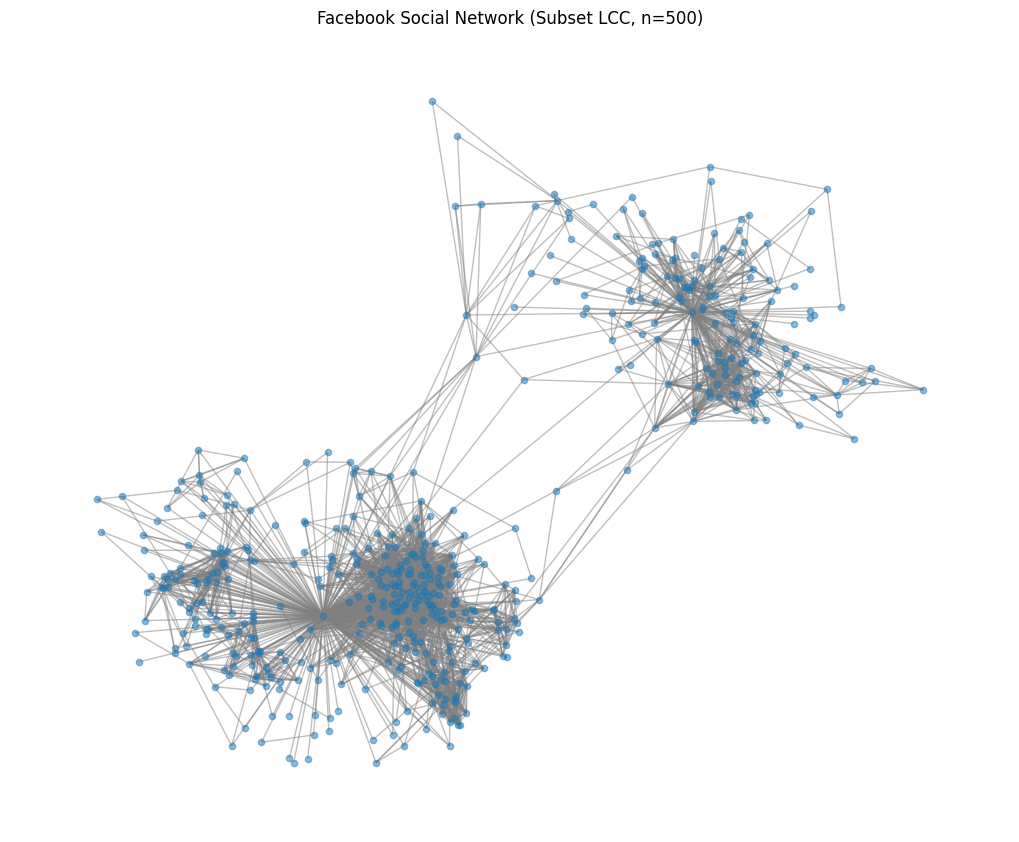

In [4]:
#Blessing Anoroh
#Assignment 3, week 3 Data 620
#Date: February 20,2026 (due : Feb 23)


# Facebook Social Network (facebook_combined.txt) in Google Colab
# Graph Analysis + Visualization
#Source: Stanford Social Circles. https://snap.stanford.edu/data/ego-Facebook.html


# Step 1: Install / Import Packages
import networkx as nx
import matplotlib.pyplot as plt


# Step 2: Upload file into Google Colab
# This is to run and select facebook_combined.txt from my computer
from google.colab import files
uploaded = files.upload()

# Now in my Google Colab directory
file_name = "facebook_combined.txt"

#Step 3 : Load graph Edge List
# Lines are: nodeA nodeB
G = nx.read_edgelist(file_name)

print("== Full Graph data ==")
print("Total Nodes:", G.number_of_nodes())
print("Total Edges:", G.number_of_edges())
print()


# Step 4: A Subset ; for clear visuals
print("Facebook graph is large 4,000 nodes. Subset makes metrics and plot fast.")
SUBSET_SIZE = 500
nodes_subset = list(G.nodes())[:SUBSET_SIZE]
G_sub = G.subgraph(nodes_subset).copy()

print("== Subset Graph data ==")
print("Subset Nodes:", G_sub.number_of_nodes())
print("Subset Edges:", G_sub.number_of_edges())
print()


# Step 5: Connected Component for Diameter
# Diameter only works on connected graphs, so we use the largest connected component.
if nx.is_connected(G_sub):
    G_lcc = G_sub
else:
    largest_cc_nodes = max(nx.connected_components(G_sub), key=len)
    G_lcc = G_sub.subgraph(largest_cc_nodes).copy()

print("== Largest Connected Component (LCC) ==")
print("LCC Nodes:", G_lcc.number_of_nodes())
print("LCC Edges:", G_lcc.number_of_edges())
print()


# Step 6: Diameter
diameter_value = nx.diameter(G_lcc)
print("Diameter (LCC):", diameter_value)
print()


# Step 7: Average Clustering Coefficient
avg_clustering = nx.average_clustering(G_lcc)
print("Average Clustering Coefficient (LCC):", round(avg_clustering, 4))
print()


#Step 8: Degree Centrality (top nodes (Top_N))
# The 10 nodes with the highest degree centrality.
# Mathematically :
#Degree centrality = # of connnections /(divided) max possible connection

degree_centrality = nx.degree_centrality(G_lcc)

TOP_N = 10
top_nodes = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:TOP_N]

print(f"Top {TOP_N} Nodes by Degree Centrality (LCC):")
for node, score in top_nodes:
    print(f"  Node {node}: {score:.4f}")
print()

# Step 9: Visualize the graph
# No labels to keep it readable.
plt.figure(figsize=(10, 8))

pos = nx.spring_layout(G_lcc, seed=42)

nx.draw(
    G_lcc,
    pos,
    with_labels=False,
    node_size=20,
    edge_color="gray",
    alpha=0.5
)

plt.title(f"Facebook Social Network (Subset LCC, n={G_lcc.number_of_nodes()})")
plt.axis("off")
plt.show()